In [6]:
train_fname = 'Train.csv'
valid_fname = 'Valid.csv'
test_fname = 'Test.csv'

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
from matplotlib import pyplot as plt
from torchvision import transforms
%matplotlib inline

In [8]:
batch_size = 64
learning_rate = 1e-3
num_batches = 32
num_epochs = 20


In [9]:
# define the class for the dataset
class Dataset(data_utils.Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y
  def __getitem__(self, idx):
    return {'X': self.X[idx], 'y': self.y[idx]}
  def __len__(self):
    return len(self.X)

In [10]:
train_set = pd.read_csv(train_fname, sep='\t')
valid_set = pd.read_csv(valid_fname, sep='\t')
test_set = pd.read_csv(test_fname, sep='\t')


In [11]:
train_set.head()


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,y_1,y_2,y_3
0,0.498465,0.454478,0.038875,0.711597,0.764543,0.765388,0.613520,81.873347,5,1
1,0.611081,0.541991,0.064824,1.000000,1.000000,0.370552,0.405952,74.957788,4,1
2,0.517362,0.502124,0.014252,1.000000,0.997216,0.709604,0.498860,70.158576,4,1
3,0.592897,0.419396,0.080598,0.973454,0.699028,0.437061,0.699198,70.722440,4,1
4,0.665826,0.607968,0.016421,0.905089,0.923863,0.172058,0.259806,75.837126,4,1


In [12]:
valid_set.head()


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,y_1,y_2,y_3
0,0.242740,0.231164,0.040139,1.000000,0.945958,0.997257,0.963473,13.313392,1,0
1,0.684098,0.503045,0.017517,0.597733,0.955207,0.116088,0.497017,71.828636,4,1
2,0.402211,0.378147,0.000623,1.000000,0.977295,0.941205,0.781773,37.834730,2,0
3,0.727472,0.689011,0.040432,0.562302,0.995022,0.036967,0.107950,66.952631,4,1
4,0.634577,0.430607,0.051684,0.993382,0.829889,0.272522,0.666075,0.885879,1,0


In [13]:
test_set.head()


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,y_1,y_2,y_3
0,0.610133,0.648041,0.084981,0.887104,0.926340,0.373223,0.173592,96.226118,5,1
1,0.354035,0.227044,0.061416,0.729385,0.926277,0.975793,0.968691,16.155045,1,0
2,0.516239,0.250959,0.073421,0.410639,0.988677,0.714129,0.947973,20.855139,2,0
3,0.621290,0.230751,0.003191,0.656688,0.940041,0.330901,0.963885,64.236230,4,1
4,0.490689,0.579817,0.119517,0.991894,0.999802,0.791547,0.322315,72.321315,4,1


In [14]:
len(train_set)


4000

In [15]:
len(valid_set)


500

In [16]:
len(test_set)


500

In [17]:
# define the independent and dependent variables
X_features = ["feature_1", "feature_2", "feature_3", "feature_4", "feature_5", "feature_6", "feature_7"]
y_feature = ["y_1"]


In [18]:
# get the values for the independent and dependent variables
train_X_pd, train_y_pd = train_set[X_features], train_set[y_feature]
valid_X_pd, valid_y_pd = valid_set[X_features], valid_set[y_feature]

In [19]:
# construct a tensor for the train dataset
train_X = torch.from_numpy(train_X_pd.astype(float).values)
train_y = torch.from_numpy(train_y_pd.astype(float).values)


In [20]:
# construct a tensor for the validation dataset
valid_X = torch.from_numpy(valid_X_pd.astype(float).values)
valid_y = torch.from_numpy(valid_y_pd.astype(float).values)


In [21]:
# set up the train dataset
train = data_utils.TensorDataset(train_X, train_y)
train_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)


In [22]:
valid = data_utils.TensorDataset(valid_X, valid_y)
valid_loader = data_utils.DataLoader(valid, batch_size=batch_size, shuffle=False)


In [23]:
train = Dataset(train_X, train_y)
train_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)


In [24]:
valid = Dataset(valid_X, valid_y)
valid_loader = data_utils.DataLoader(valid, batch_size=batch_size, shuffle=False)


In [25]:
use_cuda = torch.cuda.is_available()

In [26]:
class DNN(nn.Module):
  def __init__(self):
    super(DNN, self).__init__()
    h1 = nn.Linear(len(X_features), 50)
    h2 = nn.Linear(50, 35)
    h3 = nn.Linear(35, 1)
    self.hidden = nn.Sequential(
      h1,
      nn.ReLU(),
      #nn.Dropout(0.1),
      h2,
      nn.ReLU(),
      #nn.Dropout(0.1),
      h3,
      nn.ReLU(),
      #nn.Dropout(0.1)
    )
    if use_cuda:
      self.hidden = self.hidden.cuda()
  def forward(self, x):
    o = self.hidden(x)
    return o.view(-1).float()

In [27]:
model = DNN()

In [28]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [29]:
train_loss_list = []
valid_loss_list = []
for epoch in range(num_epochs):
    train_loss_summary = 0.0
    for i, train in enumerate(train_loader):
      train_X, train_y = train['X'], train['y']
      if use_cuda:
        train_X, train_y = train_X.cuda(), train_y.cuda()
      optimizer.zero_grad()
      train_pred = model(train_X.float())
      train_loss = criterion(train_pred, train_y.float())
      train_loss.backward()
      optimizer.step()
      train_loss_summary += train_loss
      if (i+1) % 15 == 0:
        with torch.no_grad():
          valid_loss_summary = 0.0
          for j, valid in enumerate(valid_loader):
            valid_X, valid_y = valid['X'], valid['y']
            if use_cuda:
              valid_X, valid_y = valid_X.cuda(), valid_y.cuda()
            valid_pred = model(valid_X.float())
            valid_loss = criterion(valid_pred, valid_y.float())
            valid_loss_summary += valid_loss
        print("epoch: {}/{} | step: {}/{} | train_loss: {:.4f} | val_loss: {:.4f}".format(epoch + 1, num_epochs, i+1, num_batches, (train_loss_summary/15)**(1/2), (valid_loss_summary/len(valid_loader))**(1/2)))
        train_loss_list.append((train_loss_summary/15)**(1/2))
        valid_loss_list.append((valid_loss_summary/len(valid_loader))**(1/2))
        train_loss_summary = 0.0
print("Finish Training")


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([52, 1])) that is different to the input size (torch.Size([52])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch: 1/20 | step: 15/32 | train_loss: 57.5269 | val_loss: 57.9229
epoch: 1/20 | step: 30/32 | train_loss: 57.2118 | val_loss: 57.4062
epoch: 1/20 | step: 45/32 | train_loss: 57.2336 | val_loss: 56.4780
epoch: 1/20 | step: 60/32 | train_loss: 55.5047 | val_loss: 54.8432
epoch: 2/20 | step: 15/32 | train_loss: 52.9318 | val_loss: 51.5278
epoch: 2/20 | step: 30/32 | train_loss: 50.6586 | val_loss: 47.3516


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch: 2/20 | step: 45/32 | train_loss: 44.2884 | val_loss: 42.1493
epoch: 2/20 | step: 60/32 | train_loss: 38.4760 | val_loss: 36.5752
epoch: 3/20 | step: 15/32 | train_loss: 33.4801 | val_loss: 31.3227
epoch: 3/20 | step: 30/32 | train_loss: 30.3029 | val_loss: 29.3653
epoch: 3/20 | step: 45/32 | train_loss: 28.7437 | val_loss: 28.9959
epoch: 3/20 | step: 60/32 | train_loss: 29.7989 | val_loss: 28.9834
epoch: 4/20 | step: 15/32 | train_loss: 29.5160 | val_loss: 28.9794
epoch: 4/20 | step: 30/32 | train_loss: 29.7896 | val_loss: 29.0133
epoch: 4/20 | step: 45/32 | train_loss: 28.8252 | val_loss: 29.0004
epoch: 4/20 | step: 60/32 | train_loss: 28.8721 | val_loss: 28.9887
epoch: 5/20 | step: 15/32 | train_loss: 29.4074 | val_loss: 28.9584
epoch: 5/20 | step: 30/32 | train_loss: 29.2646 | val_loss: 28.9513
epoch: 5/20 | step: 45/32 | train_loss: 28.9956 | val_loss: 28.9620
epoch: 5/20 | step: 60/32 | train_loss: 29.4510 | val_loss: 28.9662
epoch: 6/20 | step: 15/32 | train_loss: 29.6999 

In [30]:
c_train_loss_list = torch.tensor(train_loss_list, device='cpu')
c_valid_loss_list = torch.tensor(valid_loss_list, device='cpu')

Text(0, 0.5, 'loss')

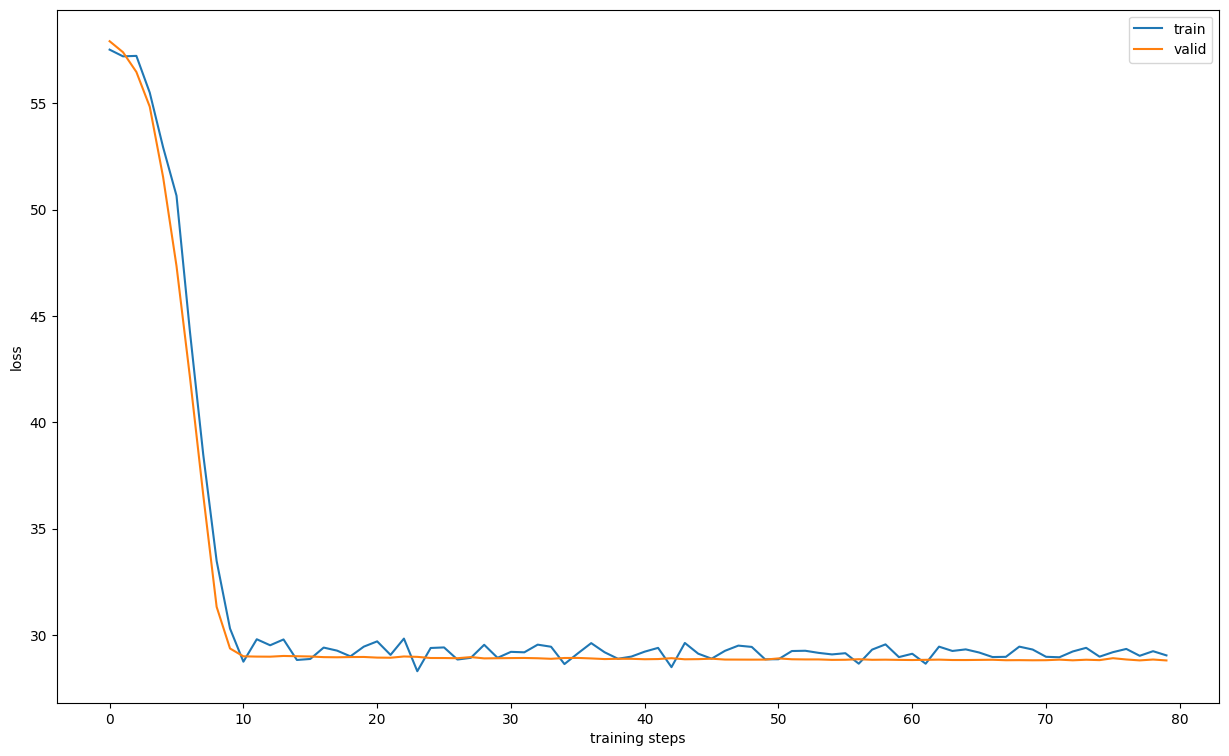

In [31]:
x_range = range(len(train_loss_list))
plt.figure(figsize=(15,9))
plt.plot(x_range, c_train_loss_list, label="train")
plt.plot(x_range, c_valid_loss_list, label="valid")
plt.legend()
plt.xlabel("training steps")
plt.ylabel("loss")

In [32]:
sample = pd.DataFrame([(0.610132650, 0.648041117, 0.084980525, 0.887103693, 0.926340235,0.373222805, 0.173592388, 0)], columns = ["feature_1", "feature_2", "feature_3", "feature_4", "feature_5", "feature_6", "feature_7", "y_1"])


In [33]:
test_X_pd, test_y_pd = sample[X_features], sample[y_feature]


In [34]:
test_X = torch.from_numpy(test_X_pd.astype(float).values)


In [35]:
test_pred = model(test_X.float())

In [36]:
print(test_pred)


tensor([50.9040], grad_fn=<ViewBackward0>)


In [37]:
from sklearn.metrics import mean_squared_error


In [38]:
test_X_pd, test_y_pd = test_set[X_features], test_set[y_feature]


In [39]:
test_X = torch.from_numpy(test_X_pd.astype(float).values)
test_y = torch.from_numpy(test_y_pd.astype(float).values)

In [40]:
test = data_utils.TensorDataset(test_X, test_y)
test_loader = data_utils.DataLoader(test, batch_size=batch_size, shuffle=True)

In [41]:
test = Dataset(test_X, test_y)
test_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)

In [42]:
test_pred = model(test_X.float())

In [43]:
y = test_y.detach().numpy()


In [44]:
y_pred = test_pred.detach().numpy()

In [45]:
RMSE = round(mean_squared_error(y, y_pred)**0.5, 3)

In [46]:
print(RMSE)

29.054


In [50]:
X_features = ["feature_1", "feature_2", "feature_3", "feature_4", "feature_5", "feature_6", "feature_7"]
y_feature = ["y_2"]

In [51]:
train_X_pd, train_y_pd = train_set[X_features], train_set[y_feature]
valid_X_pd, valid_y_pd = valid_set[X_features], valid_set[y_feature]

In [52]:
train_X = torch.from_numpy(train_X_pd.astype(float).values)
train_y = torch.from_numpy(train_y_pd.astype(float).values)

In [53]:
valid_X = torch.from_numpy(valid_X_pd.astype(float).values)
valid_y = torch.from_numpy(valid_y_pd.astype(float).values)


In [54]:
train = data_utils.TensorDataset(train_X, train_y)
train_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)

In [55]:
valid = data_utils.TensorDataset(valid_X, valid_y)
valid_loader = data_utils.DataLoader(valid, batch_size=batch_size, shuffle=False)

In [56]:
train = Dataset(train_X, train_y)
train_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)

In [57]:
valid = Dataset(valid_X, valid_y)
valid_loader = data_utils.DataLoader(valid, batch_size=batch_size, shuffle=False)

In [58]:
use_cuda = torch.cuda.is_available()

In [59]:
class DNN(nn.Module):
  def __init__(self):
    super(DNN, self).__init__()
    h1 = nn.Linear(len(X_features), 50)
    h2 = nn.Linear(50, 35)
    h3 = nn.Linear(35, 5)
    self.hidden = nn.Sequential(
      h1,
      nn.ReLU(),
      h2,
      nn.ReLU(),
      h3,
      nn.Softmax(dim=1),
    )
    if use_cuda:
      self.hidden = self.hidden.cuda()
  def forward(self, x):
    o = self.hidden(x)
    return o.float()


In [60]:
model = DNN()


In [61]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [63]:
train_loss_list = []
valid_loss_list = []
for epoch in range(num_epochs):
  train_loss_summary = 0.0
  for i, train in enumerate(train_loader):
      train_X, train_y = train['X'], train['y']
      if use_cuda:
        train_X, train_y = train_X.cuda(), train_y.cuda()
      optimizer.zero_grad()
      train_pred = model(train_X.float())
      train_pred = torch.argmax(train_pred, dim=1).float() + 1
      train_y = train_y.float().flatten()
      train_loss = criterion(train_pred, train_y)
      train_loss.requires_grad_(True)
      train_loss.backward()
      optimizer.step()
      train_loss_summary += train_loss
      if (i+1) % 15 == 0:
        with torch.no_grad():
          valid_loss_summary = 0.0
          for j, valid in enumerate(valid_loader):
            valid_X, valid_y = valid['X'], valid['y']
            if use_cuda:
              valid_X, valid_y = valid_X.cuda(), valid_y.cuda()
            valid_pred = model(valid_X.float())
            valid_pred = torch.argmax(valid_pred, dim=1).float()
            valid_y = valid_y.float().flatten()
            valid_loss = criterion(valid_pred, valid_y)
            valid_loss_summary += valid_loss
        print("epoch: {}/{} | step: {}/{} | train_loss: {:.4f} | val_loss: {:.4f}".format(epoch + 1, num_epochs, i+1, num_batches, (train_loss_summary/15)**(1/2), (valid_loss_summary/len(valid_loader))**(1/2)))
        train_loss_list.append((train_loss_summary/15)**(1/2))
        valid_loss_list.append((valid_loss_summary/len(valid_loader))**(1/2))
        train_loss_summary = 0.0
print("Finish Training")


epoch: 1/20 | step: 15/32 | train_loss: 28.2922 | val_loss: 27.8671
epoch: 1/20 | step: 30/32 | train_loss: 28.3998 | val_loss: 27.8671
epoch: 1/20 | step: 45/32 | train_loss: 28.3313 | val_loss: 27.8671
epoch: 1/20 | step: 60/32 | train_loss: 28.0313 | val_loss: 27.8671
epoch: 2/20 | step: 15/32 | train_loss: 28.0263 | val_loss: 27.8671
epoch: 2/20 | step: 30/32 | train_loss: 28.1891 | val_loss: 27.8671
epoch: 2/20 | step: 45/32 | train_loss: 28.3313 | val_loss: 27.8671
epoch: 2/20 | step: 60/32 | train_loss: 28.5069 | val_loss: 27.8671
epoch: 3/20 | step: 15/32 | train_loss: 28.1989 | val_loss: 27.8671
epoch: 3/20 | step: 30/32 | train_loss: 28.3069 | val_loss: 27.8671
epoch: 3/20 | step: 45/32 | train_loss: 27.9619 | val_loss: 27.8671
epoch: 3/20 | step: 60/32 | train_loss: 28.5312 | val_loss: 27.8671
epoch: 4/20 | step: 15/32 | train_loss: 28.3460 | val_loss: 27.8671
epoch: 4/20 | step: 30/32 | train_loss: 28.0016 | val_loss: 27.8671
epoch: 4/20 | step: 45/32 | train_loss: 28.2775 

In [64]:
c_train_loss_list = torch.tensor(train_loss_list, device='cpu')
c_valid_loss_list = torch.tensor(valid_loss_list, device='cpu')


Text(0, 0.5, 'loss')

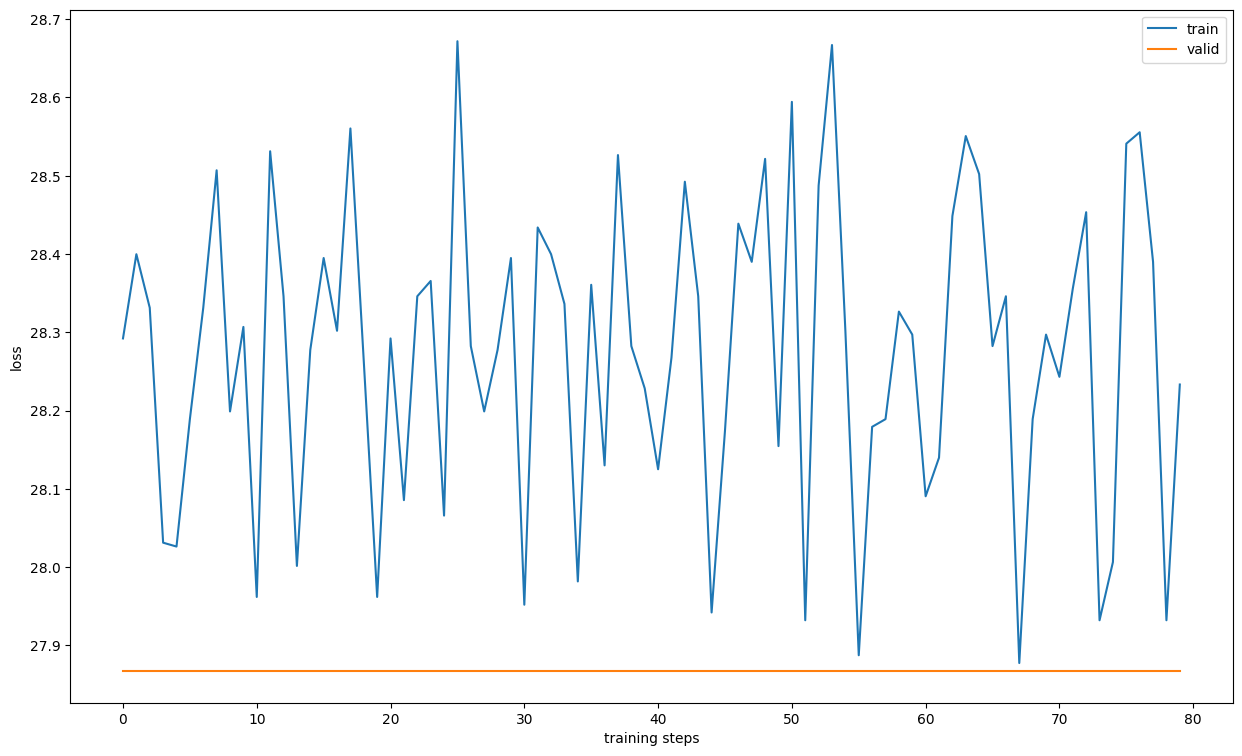

In [65]:
x_range = range(len(train_loss_list))
plt.figure(figsize=(15,9))
plt.plot(x_range, c_train_loss_list, label="train")
plt.plot(x_range, c_valid_loss_list, label="valid")
plt.legend()
plt.xlabel("training steps")
plt.ylabel("loss")


In [66]:
sample = pd.DataFrame([(0.610132650, 0.648041117, 0.084980525, 0.887103693, 0.926340235,
0.373222805, 0.173592388, 0)], columns = ["feature_1", "feature_2", "feature_3", "feature_4", "feature_5", "feature_6", "feature_7", "y_2"])

In [67]:
test_X_pd, test_y_pd = sample[X_features], sample[y_feature]


In [68]:
test_X = torch.from_numpy(test_X_pd.astype(float).values)

In [69]:
test_pred = model(test_X.float())
test_pred = torch.argmax(test_pred, dim=1).float() + 1

In [70]:
print(test_pred)

tensor([1.])


In [71]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [72]:
test_X_pd, test_y_pd = test_set[X_features], test_set[y_feature]

In [73]:
test_X = torch.from_numpy(test_X_pd.astype(float).values)
test_y = torch.from_numpy(test_y_pd.astype(float).values)


In [74]:
test = data_utils.TensorDataset(test_X, test_y)
test_loader = data_utils.DataLoader(test, batch_size=batch_size, shuffle=True)

In [75]:
test = Dataset(test_X, test_y)
test_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)

In [76]:
test_pred = model(test_X.float())

In [77]:
y = test_y.float().flatten()

In [78]:
y_pred = torch.argmax(test_pred, dim=1).float() + 1

In [79]:
confusion_matrix(y, y_pred)

array([[109,   0,   0,   0,   0],
       [105,   0,   0,   0,   0],
       [102,   0,   0,   0,   0],
       [ 92,   0,   0,   0,   0],
       [ 92,   0,   0,   0,   0]])

In [80]:
a_value = round(accuracy_score(y, y_pred), 3)


In [81]:
print("Accuracy: " + str(a_value))

Accuracy: 0.218


In [82]:
X_features = ["feature_1", "feature_2", "feature_3", "feature_4", "feature_5", "feature_6", "feature_7"]
y_feature = ["y_3"]

In [83]:
train_X_pd, train_y_pd = train_set[X_features], train_set[y_feature]
valid_X_pd, valid_y_pd = valid_set[X_features], valid_set[y_feature]


In [84]:
train_X = torch.from_numpy(train_X_pd.astype(float).values)
train_y = torch.from_numpy(train_y_pd.astype(float).values)

In [85]:
valid_X = torch.from_numpy(valid_X_pd.astype(float).values)
valid_y = torch.from_numpy(valid_y_pd.astype(float).values)

In [86]:
train = data_utils.TensorDataset(train_X, train_y)
train_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)

In [87]:
valid = data_utils.TensorDataset(valid_X, valid_y)
valid_loader = data_utils.DataLoader(valid, batch_size=batch_size, shuffle=False)

In [88]:
train = Dataset(train_X, train_y)
train_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)

In [89]:
valid = Dataset(valid_X, valid_y)
valid_loader = data_utils.DataLoader(valid, batch_size=batch_size, shuffle=False)

In [90]:
use_cuda = torch.cuda.is_available()


In [91]:
class DNN(nn.Module):
  def __init__(self):
    super(DNN, self).__init__()
    h1 = nn.Linear(len(X_features), 50)
    h2 = nn.Linear(50, 35)
    h3 = nn.Linear(35, 1)
    self.hidden = nn.Sequential(
      h1,
      nn.ReLU(),
      h2,
      nn.ReLU(),
      h3,
      nn.Sigmoid(),
    )
    if use_cuda:
      self.hidden = self.hidden.cuda()
  def forward(self, x):
    o = self.hidden(x)
    return o.view(-1).float()

In [92]:
model = DNN()

In [93]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [94]:
train_loss_list = []
valid_loss_list = []

for epoch in range(num_epochs):
  train_loss_summary = 0.0
  for i, train in enumerate(train_loader):
    train_X, train_y = train['X'], train['y']
    if use_cuda:
      train_X, train_y = train_X.cuda(), train_y.cuda()
    optimizer.zero_grad()
    train_pred = model(train_X.float())
    #train_pred = torch.round(train_pred)
    train_y = train_y.float().flatten()
    train_loss = criterion(train_pred, train_y)
    train_loss.requires_grad_(True)
    train_loss.backward()
    optimizer.step()
    train_loss_summary += train_loss
    if (i+1) % 15 == 0:
      with torch.no_grad():
        valid_loss_summary = 0.0
        for j, valid in enumerate(valid_loader):
          valid_X, valid_y = valid['X'], valid['y']
          if use_cuda:
            valid_X, valid_y = valid_X.cuda(), valid_y.cuda()
          valid_pred = model(valid_X.float())
          #valid_pred = torch.round(valid_pred)
          valid_y = valid_y.float().flatten()
          valid_loss = criterion(valid_pred, valid_y)
          valid_loss_summary += valid_loss
      print("epoch: {}/{} | step: {}/{} | train_loss: {:.4f} | val_loss: {:.4f}".format(epoch + 1, num_epochs, i+1, num_batches, (train_loss_summary/15)**(1/2), (valid_loss_summary/len(valid_loader))**(1/2)))
      train_loss_list.append((train_loss_summary/15)**(1/2))
      valid_loss_list.append((valid_loss_summary/len(valid_loader))**(1/2))
      train_loss_summary = 0.0
print("Finish Training")


epoch: 1/20 | step: 15/32 | train_loss: 0.8361 | val_loss: 0.8309
epoch: 1/20 | step: 30/32 | train_loss: 0.8278 | val_loss: 0.8283
epoch: 1/20 | step: 45/32 | train_loss: 0.8283 | val_loss: 0.8244
epoch: 1/20 | step: 60/32 | train_loss: 0.8229 | val_loss: 0.8200
epoch: 2/20 | step: 15/32 | train_loss: 0.8186 | val_loss: 0.8145
epoch: 2/20 | step: 30/32 | train_loss: 0.8143 | val_loss: 0.8105
epoch: 2/20 | step: 45/32 | train_loss: 0.8081 | val_loss: 0.8063
epoch: 2/20 | step: 60/32 | train_loss: 0.8068 | val_loss: 0.8042
epoch: 3/20 | step: 15/32 | train_loss: 0.8031 | val_loss: 0.8032
epoch: 3/20 | step: 30/32 | train_loss: 0.8037 | val_loss: 0.8011
epoch: 3/20 | step: 45/32 | train_loss: 0.8028 | val_loss: 0.8021
epoch: 3/20 | step: 60/32 | train_loss: 0.8099 | val_loss: 0.8007
epoch: 4/20 | step: 15/32 | train_loss: 0.8031 | val_loss: 0.8016
epoch: 4/20 | step: 30/32 | train_loss: 0.8026 | val_loss: 0.8016
epoch: 4/20 | step: 45/32 | train_loss: 0.8026 | val_loss: 0.8004
epoch: 4/2

In [95]:
c_train_loss_list = torch.tensor(train_loss_list, device='cpu')
c_valid_loss_list = torch.tensor(valid_loss_list, device='cpu')


Text(0, 0.5, 'loss')

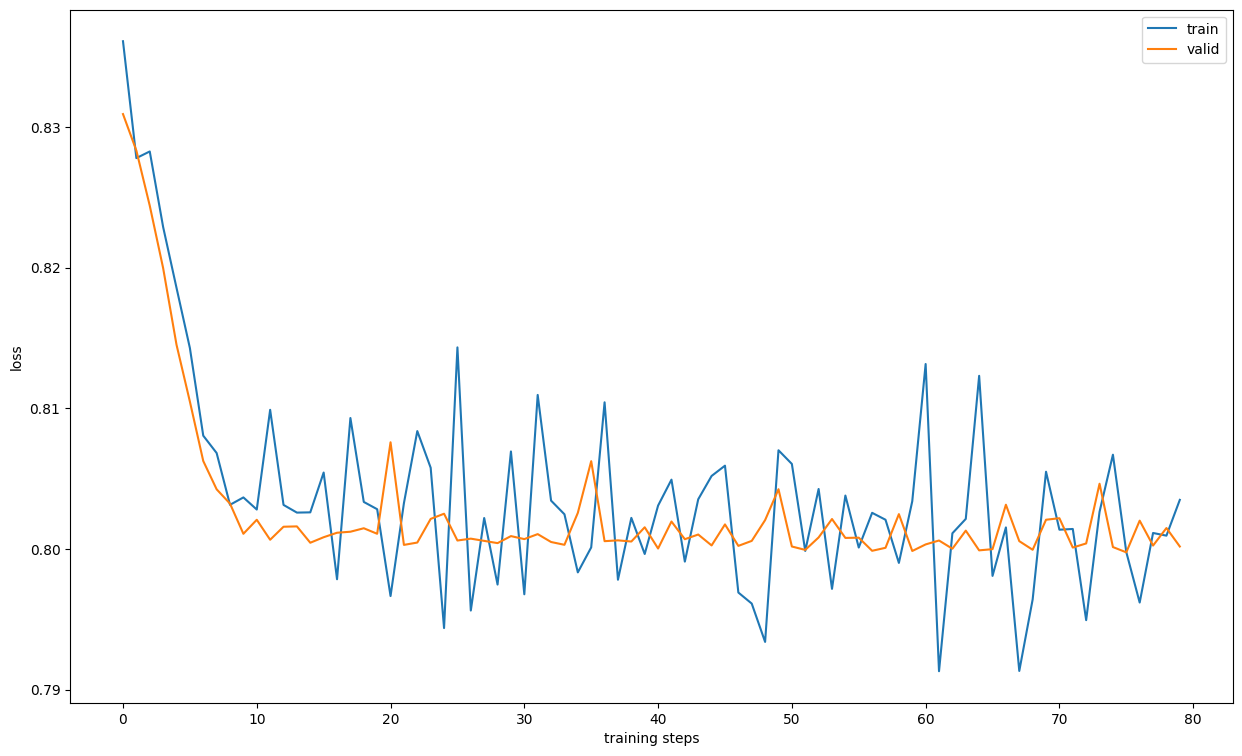

In [96]:
x_range = range(len(train_loss_list))
plt.figure(figsize=(15,9))
plt.plot(x_range, c_train_loss_list, label="train")
plt.plot(x_range, c_valid_loss_list, label="valid")
plt.legend()
plt.xlabel("training steps")
plt.ylabel("loss")


In [97]:
sample = pd.DataFrame([(0.610132650, 0.648041117, 0.084980525, 0.887103693, 0.926340235,0.373222805, 0.173592388, 0)], columns = ["feature_1", "feature_2", "feature_3", "feature_4", "feature_5", "feature_6", "feature_7", "y_3"])

In [98]:
test_X_pd, test_y_pd = sample[X_features], sample[y_feature]

In [99]:
test_X = torch.from_numpy(test_X_pd.astype(float).values)

In [100]:
test_logits = model(test_X.float())
test_pred = torch.round(test_logits)

In [101]:
test_pred = test_pred.detach().numpy().flatten()

In [102]:
print(test_pred)

[1.]


In [104]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

In [105]:
test_X_pd, test_y_pd = test_set[X_features], test_set[y_feature]

In [106]:
test_X = torch.from_numpy(test_X_pd.astype(float).values)
test_y = torch.from_numpy(test_y_pd.astype(float).values)

In [107]:
test = data_utils.TensorDataset(test_X, test_y)
test_loader = data_utils.DataLoader(test, batch_size=batch_size, shuffle=True)

In [108]:
test = Dataset(test_X, test_y)
test_loader = data_utils.DataLoader(train, batch_size=batch_size, shuffle=True)


In [109]:
test_logits = model(test_X.float())
test_pred = torch.round(test_logits)

In [110]:
y = test_y.detach().flatten()


In [111]:
y_pred = test_pred.detach().numpy().flatten()

In [112]:
confusion_matrix(y, y_pred)


array([[177,  90],
       [ 95, 138]])

In [113]:
p_value = round(precision_score(y, y_pred), 3)
r_value = round(recall_score(y, y_pred), 3)
f_value = round(f1_score(y, y_pred), 3)
a_value = round(accuracy_score(y, y_pred), 3)

In [114]:
print("Precision: " + str(p_value) + " " + "Recall: " + str(r_value) + " " + "F1-score: " + str(f_value) + " " + "Accuracy: " + str(a_value))

Precision: 0.605 Recall: 0.592 F1-score: 0.599 Accuracy: 0.63
